In [131]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import seaborn as sns
import matplotlib as mpl

# Styling: use Arial font and seaborn theme
plt.rcParams['font.family'] = 'Arial'
# Keep text as real text in SVG (do not convert to paths/outlines)
mpl.rcParams['svg.fonttype'] = 'none'
# Prefer transparent backgrounds when saving
mpl.rcParams['savefig.transparent'] = True
# sns.set(style='whitegrid', context='notebook', font_scale=1.1)


In [132]:
# Choose dataset folder under `results` (just the dataset name, not a path)
dataset = 'UniToPatho'  # change to 'GCHTID' or 'WSSS4LUAD' as needed
# dataset = 'GCHTID'
root = os.path.join('/jhcnas3/VirtualStaining/downstream_tasks', 'results', dataset)
models = ['HE', 'bci', 'p2p', 'cyclegan', 'her2', 'reggan', 'unsb', 'stegogan', 'asp', 'st', 'ours_512']

display_names = {
    'HE': 'HE',
    'bci': 'BCI',
    'p2p': 'Pix2pix',
    'cyclegan': 'CycleGAN',
    'her2': 'Her2',
    'reggan': 'RegGAN',
    'unsb': 'UNSB',
    'stegogan': 'StegoGAN',
    'asp': 'ASP',
    'st': 'ST',
    'ours_512': 'DGR'
}

acc = []
acc_err = []
f1 = []
f1_err = []
labels = []

he_cm = None
DGR_cm = None

for model in models:
    result_path = os.path.join(root, model, 'test_results.json')
    try:
        with open(result_path, 'r') as f:
            results = json.load(f)
    except Exception:
        # skip missing or unreadable results
        continue

    accuracy = results.get('accuracy', None)
    acc_low = results.get('accuracy_ci_lower', None)
    acc_up = results.get('accuracy_ci_upper', None)

    if model == 'HE':
        he_cm = np.array(results.get('confusion_matrix', None))
    if model == 'ours_512':
        DGR_cm = np.array(results.get('confusion_matrix', None))

    if accuracy is None:
        continue

    # map display name for ours_512
    disp_name = display_names.get(model, model)
    labels.append(disp_name)
    # Normalize to fraction in [0,1]: if value >1 we assume percent and divide by 100
    acc_val = accuracy if accuracy <= 1.0 else (accuracy / 100.0)
    acc.append(acc_val)

    if acc_low is not None and acc_up is not None:
        # compute symmetric errors as fractions
        lower = (accuracy - acc_low) if accuracy <= 1.0 else ((accuracy - acc_low) / 100.0)
        upper = (acc_up - accuracy) if accuracy <= 1.0 else ((acc_up - accuracy) / 100.0)
        err = np.array([lower, upper])
        acc_err.append(err)
    else:
        acc_err.append(np.array([0.0, 0.0]))

    f1_score = results.get('f1_score', None)
    if f1_score is None:
        f1.append(0.0)
        f1_err.append(np.array([0.0, 0.0]))
    else:
        f1_val = f1_score if f1_score <= 1.0 else (f1_score / 100.0)
        f1.append(f1_val)
        f1_low = results.get('f1_ci_lower', None)
        f1_up = results.get('f1_ci_upper', None)
        if f1_low is not None and f1_up is not None:
            lower = (f1_score - f1_low) if f1_score <= 1.0 else ((f1_score - f1_low) / 100.0)
            upper = (f1_up - f1_score) if f1_score <= 1.0 else ((f1_up - f1_score) / 100.0)
            f1_err.append(np.array([lower, upper]))
        else:
            f1_err.append(np.array([0.0, 0.0]))



Saved PDF: UniToPatho_metrics_bars.pdf


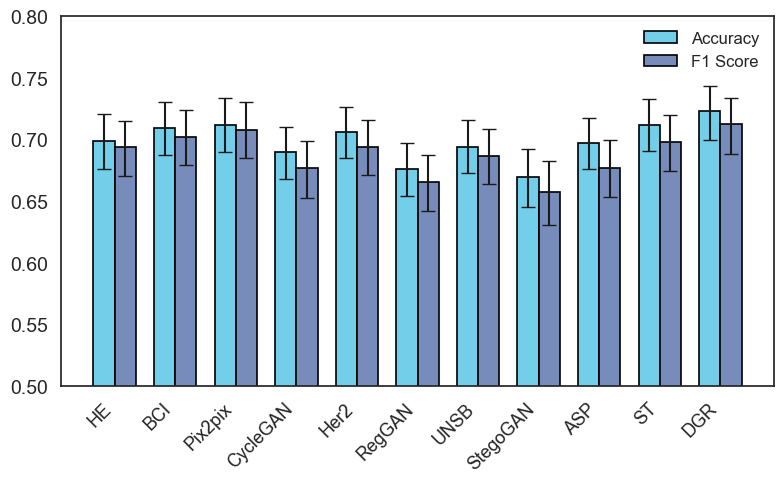

In [133]:
# Convert to numpy arrays for plotting
acc = np.array(acc)
f1 = np.array(f1)
acc_err = np.array(acc_err).T if len(acc_err) > 0 else np.zeros((2, len(acc)))
f1_err = np.array(f1_err).T if len(f1_err) > 0 else np.zeros((2, len(f1)))

# Prepare the bar plot: side-by-side bars with error bars
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.6), 5))
# Use the provided color scheme (normalized RGB)
color_blue = (115/255, 207/255, 233/255)
color_purple = (120/255, 140/255, 188/255)
color_pink = (232/255, 157/255, 166/255)
colors = [color_blue, color_purple]
# Slightly darker edge colors for subtle borders
edge_blue = tuple([c * 0.6 for c in [0, 0, 0]])
edge_purple = tuple([c * 0.6 for c in [0, 0, 0]])

# Add edgecolor and increased linewidth to give bars a bold border
bars1 = ax.bar(x - width/2, acc, width, yerr=acc_err, label='Accuracy', color=colors[0], edgecolor=edge_blue, linewidth=1.2, capsize=5)
bars2 = ax.bar(x + width/2, f1, width, yerr=f1_err, label='F1 Score', color=colors[1], edgecolor=edge_purple, linewidth=1.2, capsize=5)

# No per-bar numeric annotations as requested

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
# Make y-axis label and tick labels larger for readability
# ax.set_ylabel('Metric Score', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=13)
# y-axis starts at 0.5 as requested; upper bound scales with data

# y_max = max(1.0, (np.nanmax(np.concatenate([acc, f1])) * 1.05) if len(acc) else 1.0)
if dataset == 'UniToPatho':
    y_max = 0.8
    y_min = 0.5
elif dataset == 'GCHTID':
    y_max = 0.7
    y_min = 0.6
    
ax.set_ylim(y_min, y_max)
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()

# Save SVG (file name only will be shown in output to avoid printing full paths)
out_svg = os.path.join(root, f'{dataset}_metrics_bars.pdf')
# Ensure figure and axes backgrounds are transparent and text remains as text in the SVG
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
fig.savefig(out_svg, format='pdf', dpi=300, transparent=True, facecolor='none', bbox_inches='tight')
print('Saved PDF:', os.path.basename(out_svg))
plt.show()


In [134]:
unitopatho_label_names = {0: "HP",
1: "NORM",
2: "TA.HG",
3: "TA.LG",
4: "TVA.HG",
5: "TVA.LG"
}
gchtid_label_names = {0: "ADI",
1: "DEB",
2: "LYM",
3: "MUC",
4: "MUS",
5: "NOR",
6: "STR",
7: "TUM"}

Saved confusion matrix: UniToPatho_HE_confusion.pdf


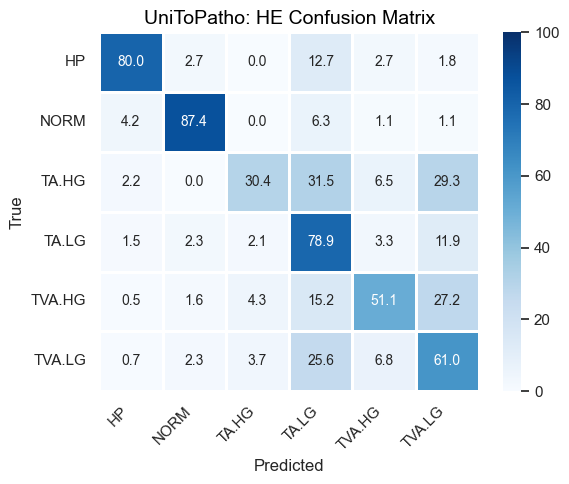

Saved confusion matrix: UniToPatho_DGR_confusion.pdf


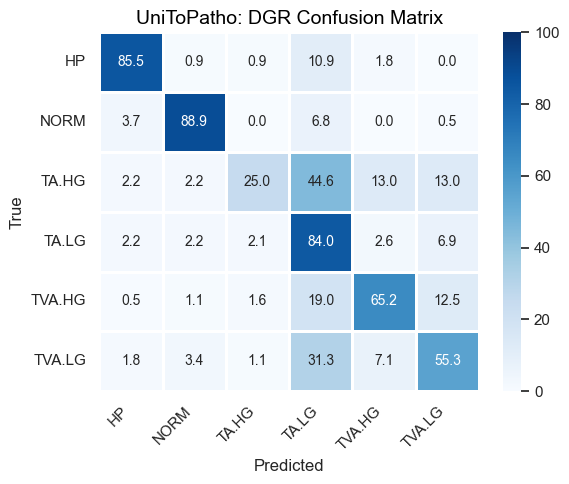

In [135]:
# 绘制并美化 HE 与 DGR 的混淆矩阵，并保存为透明 SVG
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(cm, title, labels=None, out_path=None, cmap='Blues'):
    if cm is None:
        print(f"No confusion matrix for {title}")
        return
    cm = np.array(cm)
    # avoid division by zero
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(invalid='ignore', divide='ignore'):
        cm_percent = (cm / row_sums) * 100
        cm_percent = np.nan_to_num(cm_percent)

    # cm_percent = cm
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.set(style='white')
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap=cmap, cbar=True,
                xticklabels=labels if labels is not None else np.arange(cm.shape[1]),
                yticklabels=labels if labels is not None else np.arange(cm.shape[0]),
                vmin=0, vmax=100, annot_kws={'size':10}, ax=ax,
                linewidths=0.8, linecolor='white')

    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14, color='black')
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)

    # make axis spines invisible for a cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    if out_path:
        fig.patch.set_alpha(0.0)
        ax.set_facecolor('none')
        fig.savefig(out_path, format='pdf', dpi=300, transparent=True, bbox_inches='tight')
        print('Saved confusion matrix:', os.path.basename(out_path))
    plt.show()

# choose label names based on dataset
labels = None
if dataset == 'UniToPatho' and unitopatho_label_names is not None:
    labels = [unitopatho_label_names[i] for i in sorted(unitopatho_label_names.keys())]
elif dataset == 'GCHTID' and gchtid_label_names is not None:
    labels = [gchtid_label_names[i] for i in sorted(gchtid_label_names.keys())]

out_dir = root
os.makedirs(out_dir, exist_ok=True)
color = 'Blues' 
# color = 'Purples'
plot_confusion(he_cm, f'{dataset}: HE Confusion Matrix', labels=labels, out_path=os.path.join(out_dir, f'{dataset}_HE_confusion.pdf'), cmap=color)
plot_confusion(DGR_cm, f'{dataset}: DGR Confusion Matrix', labels=labels, out_path=os.path.join(out_dir, f'{dataset}_DGR_confusion.pdf'), cmap=color)
